**Step 1: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 2: Import Required Libraries**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Step 3: Define Paths for the Eyes Dataset**

Here i will process only the Eyes folder for DownSyndrome and Healthy.

In [ ]:
#Defining source and destination paths for Eyes part
source_dir = '/content/drive/My Drive/Face_Fea_Extract'
destination_dir = '/content/drive/My Drive/FaceClassificationData/Eyes'


classes = {"DownSyndrome": "1", "Healthy": "0"}

#Creating Train and Val directories/folders for Eyes
for split in ['Train', 'Val']:
    for class_label in classes.values():
        os.makedirs(os.path.join(destination_dir, split, class_label), exist_ok=True)

print("Directory structure for Eyes created successfully!")

Directory structure for Eyes created successfully!


**Step 4: Dataset Splitting for Eyes**

This step will split the Eyes dataset into Train and Val for both classes.

In [ ]:
#Splitting and organize Eyes data
for class_name, label in classes.items():
    #The Path to the Eyes folder for each class
    class_path = os.path.join(source_dir, class_name, 'Eyes')
    all_images = []

    # Collecting all images from Eyes folder
    for file in os.listdir(class_path):
        if file.endswith(('.jpg', '.png')):
            all_images.append(os.path.join(class_path, file))

    #Splitting into Train and Val
    train_images, val_images = train_test_split(all_images, train_size=0.8, random_state=42)

    #Copying files to Train and Val directories
    for img in train_images:
        shutil.copy(img, os.path.join(destination_dir, 'Train', label))
    for img in val_images:
        shutil.copy(img, os.path.join(destination_dir, 'Val', label))

print("Eyes dataset split and organized successfully!")

Eyes dataset split and organized successfully!


**Step 5: Verify Folder Contents**

Checking if the images are splitted correctly into Train and Val.

In [ ]:
#Verifying Train folder for Healthy
!ls '/content/drive/My Drive/FaceClassificationData/Eyes/Train/0'

#Verifying Train folder for DownSyndrome
!ls '/content/drive/My Drive/FaceClassificationData/Eyes/Train/1'

eyes_healty_1000.jpg  eyes_healty_1334.jpg  eyes_healty_336.jpg  eyes_healty_679.jpg
eyes_healty_1001.jpg  eyes_healty_1335.jpg  eyes_healty_338.jpg  eyes_healty_67.jpg
eyes_healty_1003.jpg  eyes_healty_1336.jpg  eyes_healty_33.jpg	 eyes_healty_680.jpg
eyes_healty_1004.jpg  eyes_healty_1337.jpg  eyes_healty_340.jpg  eyes_healty_682.jpg
eyes_healty_1005.jpg  eyes_healty_133.jpg   eyes_healty_341.jpg  eyes_healty_683.jpg
eyes_healty_1006.jpg  eyes_healty_1340.jpg  eyes_healty_342.jpg  eyes_healty_684.jpg
eyes_healty_1007.jpg  eyes_healty_1342.jpg  eyes_healty_345.jpg  eyes_healty_685.jpg
eyes_healty_1009.jpg  eyes_healty_1343.jpg  eyes_healty_346.jpg  eyes_healty_686.jpg
eyes_healty_100.jpg   eyes_healty_1344.jpg  eyes_healty_347.jpg  eyes_healty_687.jpg
eyes_healty_1010.jpg  eyes_healty_1345.jpg  eyes_healty_348.jpg  eyes_healty_689.jpg
eyes_healty_1011.jpg  eyes_healty_1346.jpg  eyes_healty_34.jpg	 eyes_healty_68.jpg
eyes_healty_1012.jpg  eyes_healty_1347.jpg  eyes_healty_353.jpg  eyes

**Step 6: Visualize Sample Images**

Healthy Eyes - Train:


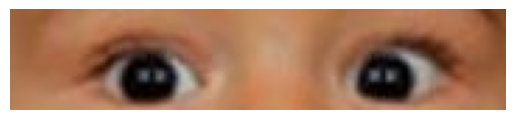

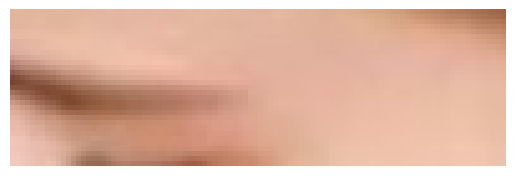

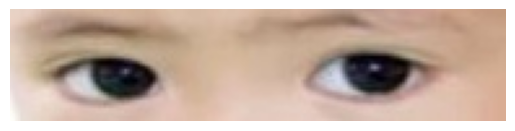

Down Syndrome Eyes - Train:


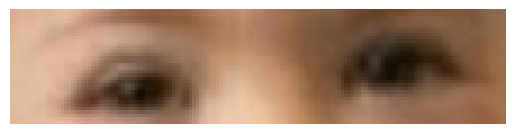

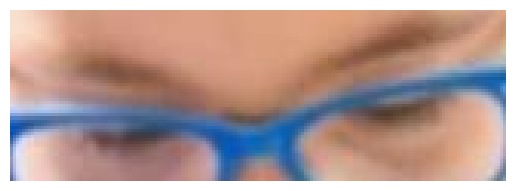

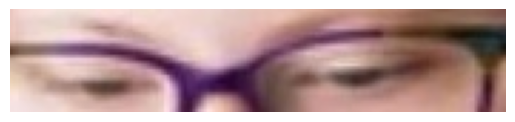

In [ ]:
#Function to display sample images
def display_samples(path, num_samples=3):
    images = [os.path.join(path, img) for img in os.listdir(path)[:num_samples]]
    for img_path in images:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

#Displaying samples for Healthy Eyes
print("Healthy Eyes - Train:")
display_samples('/content/drive/My Drive/FaceClassificationData/Eyes/Train/0')

#Displaying samples for DownSyndrome Eyes
print("Down Syndrome Eyes - Train:")
display_samples('/content/drive/My Drive/FaceClassificationData/Eyes/Train/1')

**Step 7: Install YOLO Framework**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 896.3/896.3 kB 23.8 MB/s eta 0:00:00


**Step 8: Train YOLO Model**

In [ ]:
from ultralytics import YOLO

#Loading YOLO model
model = YOLO("yolo11n-cls.pt")  #checkpoint

#Training the model using the corrected Eyes dataset
results = model.train(
    data='/content/drive/My Drive/FaceClassificationData/Eyes',  #Dataset path
    epochs=20,                  # Number of epochs
    imgsz=224,                  # Image size
    batch=16,                   # Batch size
    project="FaceClassificationResults/Eyes"  #Saving results in my specified folder
)

print("Training completed successfully!")

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolo11n-cls.pt, data=/content/drive/My Drive/FaceClassificationData/Eyes, epochs=20, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=FaceClassificationResults/Eyes, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_c

train: Scanning /content/drive/My Drive/FaceClassificationData/Eyes/train... 2374 images, 0 corrupt: 100%|██████████| 2374/2374 [00:27<00:00, 85.00it/s] 


train: New cache created: /content/drive/My Drive/FaceClassificationData/Eyes/train.cache


val: Scanning /content/drive/My Drive/FaceClassificationData/Eyes/val... 594 images, 0 corrupt: 100%|██████████| 594/594 [00:05<00:00, 101.84it/s]


val: New cache created: /content/drive/My Drive/FaceClassificationData/Eyes/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 224 train, 224 val
Using 0 dataloader workers
Logging results to FaceClassificationResults/Eyes/train5
Starting training for 20 epochs...

      Epoch    GPU_mem       loss  Instances       Size


...

      20/20         0G     0.2634          6        224: 100%|██████████| 149/149 [02:37<00:00,  1.06s/it]
               classes   top1_acc   top5_acc: 100%|██████████| 19/19 [00:16<00:00,  1.14it/s]

                   all      0.791          1



20 epochs completed in 1.012 hours.
Optimizer stripped from FaceClassificationResults/Eyes/train5/weights/last.pt, 3.2MB
Optimizer stripped from FaceClassificationResults/Eyes/train5/weights/best.pt, 3.2MB

Validating FaceClassificationResults/Eyes/train5/weights/best.pt...
Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/My Drive/FaceClassificationData/Eyes/train... found 2374 images in 2 classes ✅ 
val: /content/drive/My Drive/FaceClassificationData/Eyes/val... found 594 images in 2 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 19/19 [00:16<00:00,  1.16it/s]


                   all      0.811          1
Speed: 0.0ms preprocess, 15.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to FaceClassificationResults/Eyes/train5
Training completed successfully!


**Step 9: Validate the Model**

In [ ]:
#Validating the model using the Eyes dataset
metrics = model.val()
print("Validation Results for Eyes:", metrics)

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-cls summary (fused): 112 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/My Drive/FaceClassificationData/Eyes/train... found 2374 images in 2 classes ✅ 
val: /content/drive/My Drive/FaceClassificationData/Eyes/val... found 594 images in 2 classes ✅ 
test: None...


val: Scanning /content/drive/My Drive/FaceClassificationData/Eyes/val... 594 images, 0 corrupt: 100%|██████████| 594/594 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 38/38 [00:15<00:00,  2.42it/s]


                   all      0.811          1
Speed: 0.0ms preprocess, 14.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to FaceClassificationResults/Eyes/train52
Validation Results for Eyes: ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3113638d30>
curves: []
curves_results: []
fitness: 0.90572389960289
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.81144779920578, 'metrics/accuracy_top5': 1.0, 'fitness': 0.90572389960289}
save_dir: PosixPath('FaceClassificationResults/Eyes/train52')
speed: {'preprocess': 0.001635615673129406, 'inference': 14.0012542808096, 'loss': 0.0002982239129166009, 'postprocess': 0.00014128508391203704}
task: 'classify'
top1: 0.81144779920578
top5: 1.0


**Step 10: Analyze Predictions and Compute Metrics**

Generate Predictions and Labels

In [ ]:
#Path to validation data for Eyes
val_path = '/content/drive/My Drive/FaceClassificationData/Eyes/val'

true_labels, predicted_labels = [], []

for class_label in ["0", "1"]:  # Healthy=0, Down Syndrome=1
    class_dir = os.path.join(val_path, class_label)
    for img_file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_file)
        prediction = model(img_path, verbose=False)
        probs = prediction[0].probs
        # Use top1 attribute instead of argmax
        predicted_class = probs.top1
        true_labels.append(int(class_label))
        predicted_labels.append(predicted_class)

print("Predictions for Eyes completed!")

Predictions for Eyes completed!


Calculate and Display Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

#Calculating accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy for Eyes: {accuracy * 100:.2f}%")

Accuracy for Eyes: 81.14%


Generate Classification Report

In [ ]:
from sklearn.metrics import classification_report

#Generating classification report
report = classification_report(true_labels, predicted_labels, target_names=["Healthy", "Down Syndrome"])
print("Classification Report for Eyes:\n", report)

Classification Report for Eyes:
                precision    recall  f1-score   support

      Healthy       0.77      0.90      0.83       297
Down Syndrome       0.87      0.73      0.79       297

     accuracy                           0.81       594
    macro avg       0.82      0.81      0.81       594
 weighted avg       0.82      0.81      0.81       594



Generate Confusion Matrix

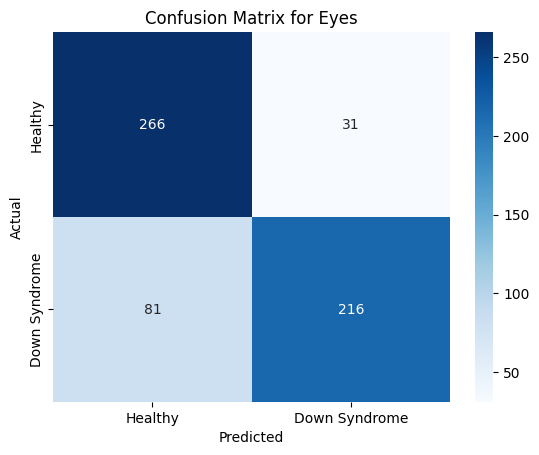

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Generating confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

#Visualizing confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Down Syndrome"], yticklabels=["Healthy", "Down Syndrome"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Eyes')
plt.show()

**Step 11: ROC Curve and AUC**

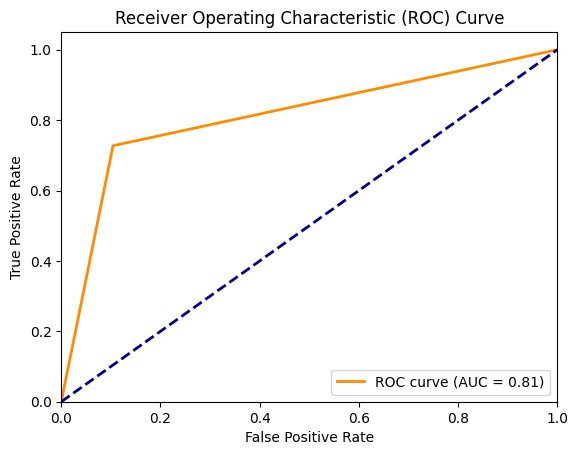

In [ ]:
from sklearn.metrics import roc_curve, auc

#Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()